# Climate-Driven Disease Surveillance

This lesson estimates climate suitability for disease outbreaks in an
approximate Kisumu County AOI. It is an environmental risk proxy, not a
diagnosis or a replacement for epidemiological surveillance.

**Learning objectives**

- connect rainfall, temperature, standing water, vegetation, and population
  exposure to disease suitability;
- interpret three risk classes and hotspot clusters;
- plot environmental indicators on separate physical scales;
- explain why climate suitability must be validated against case data.


## 1. Prepare the notebook session

This cell imports the tools used throughout the lesson and loads configuration
from a local `.env` file. The Earth Engine project identifier is configuration,
not analysis data, so it is kept outside the notebook.

Before running the notebook:

1. copy `.env.example` to `.env`;
2. replace the placeholder with your Google Earth Engine project ID;
3. run `earthengine authenticate` once in a terminal;
4. select the **Climate Change Workflows** kernel.

The `%matplotlib inline` backend renders figures directly below each plotting cell.


In [1]:
from dataclasses import asdict
from pathlib import Path
import os

from IPython import get_ipython

ipython = get_ipython()
if ipython is not None:
    ipython.run_line_magic("matplotlib", "inline")

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from dotenv import load_dotenv

from climate_change import USE_CASE_REGISTRY, run_analysis

WORKSPACE = Path.cwd()
if not (WORKSPACE / ".venv").exists() and (WORKSPACE.parent / ".venv").exists():
    WORKSPACE = WORKSPACE.parent

load_dotenv(WORKSPACE / ".env")
GEE_PROJECT = os.environ.get("GEE_PROJECT", "").strip()
if not GEE_PROJECT:
    raise RuntimeError("Create .env from .env.example and set GEE_PROJECT.")

OUTPUT_DIR = WORKSPACE / "outputs"
REPORT_DIR = WORKSPACE / "reports"
OUTPUT_DIR.mkdir(exist_ok=True)
REPORT_DIR.mkdir(exist_ok=True)

print("Workspace:", WORKSPACE)
print("Earth Engine project configured:", bool(GEE_PROJECT))


Workspace: /home/odero-george/Workspace/climate-change
Earth Engine project configured: True


## 2. Inspect the package registry

The registry is the package's catalogue of supported analyses. It documents the
recommended date range, dependent variable, input variables, and selectable models.
Inspecting it before running an analysis helps us choose scientifically sensible
parameters instead of treating the model as a black box.


In [2]:
info = USE_CASE_REGISTRY["disease"]
print(info.name)
print("\nPurpose:", info.description)
print("\nPredicted variable:", info.dependent_variable)
print("\nDate guidance:", info.date_guidance)
print("\nAvailable models:")
for option in info.model_options:
    marker = " (recommended)" if option.recommended else ""
    print(f"  - {option.id}: {option.label}{marker} — {option.note}")


Climate-Driven Disease Surveillance

Purpose: This tool maps where climate conditions — warmth, rainfall, and standing water — create the ideal environment for disease outbreaks like malaria and cholera. It shows current risk zones and provides a 4-week outbreak probability forecast.

Predicted variable: Disease outbreak risk class (Low / Medium / High) or weekly case count forecast

Date guidance: Select the most recent 3-6 months for current risk; up to 2 years for trend analysis.

Available models:
  - gbm: Gradient Boosting (recommended) — Default disease model
  - xgboost: XGBoost — High accuracy · longer run
  - ensemble: Ensemble (GBM + XGBoost) — Best overall · mean softmax


## 3. Mathematical/Scientific model

The workflow constructs a climate-suitability score:

$$
S = 0.40S_T + 0.35S_R + 0.25S_W
$$

where $S_T$ is temperature suitability, $S_R$ is rainfall suitability,
and $S_W$ represents standing-water suitability from a water index.

The machine-learning model estimates class probability:

$$
\hat{p}_k(\mathbf{x}) = P(Y=k\mid\mathbf{x}),
\qquad k\in\{\text{Low, Medium, High}\}
$$

Spatially adjacent high-risk pixels are grouped into hotspots with DBSCAN.
Climate suitability indicates favorable environmental conditions; actual
Transmission also depends on immunity, interventions, mobility, and healthcare.

## 4. Configure a climate-surveillance study

The AOI covers Kisumu and part of the Lake Victoria shoreline. The period
provides several seasonal cycles for comparing rainfall, vegetation, and
land-surface temperature.


In [3]:
aoi = {
    "type": "Polygon",
    "coordinates": [[
        [34.10, -0.80], [35.00, -0.80], [35.00, 0.20],
        [34.10, 0.20], [34.10, -0.80],
    ]],
}

analysis_args = {
    "module": "disease",
    "aoi_geojson": aoi,
    "start_date": "2021-01-01",
    "end_date": "2023-12-31",
    "country": "Kenya",
    "gee_project": GEE_PROJECT,
    "extra_params": {
        "model_type": "gbm",
        "n_pixels": 3000,
        "scale": 1000,
        "output_dir": str(OUTPUT_DIR),
        "prefix": "kisumu_disease_risk",
    },
}
analysis_args

{'module': 'disease',
 'aoi_geojson': {'type': 'Polygon',
  'coordinates': [[[34.1, -0.8],
    [35.0, -0.8],
    [35.0, 0.2],
    [34.1, 0.2],
    [34.1, -0.8]]]},
 'start_date': '2021-01-01',
 'end_date': '2023-12-31',
 'country': 'Kenya',
 'gee_project': 'parallelprocessing-433914',
 'extra_params': {'model_type': 'gbm',
  'n_pixels': 3000,
  'scale': 1000,
  'output_dir': '/home/odero-george/Workspace/climate-change/outputs',
  'prefix': 'kisumu_disease_risk'}}

## 5. Run the analysis

`run_analysis` is asynchronous because data retrieval and model execution may be
long-running operations. Jupyter supports top-level `await`, so no explicit event
loop is required here.

The first run may take several minutes. Runtime depends on AOI size, temporal
coverage, Earth Engine quota, sampling resolution, and model choice.


In [4]:
output = await run_analysis(**analysis_args)
print("Analysis complete:", output.module)

Enter verification code:  4/1AXEQxIAsmknvq1DCSYAbxasZ-7PpW0r-TIOARrw_okRnQtcH5B1Rd61B3sU



Successfully saved authorization token.


2026-08-13 18:35:51,367 - distributed.http.proxy - INFO - To route to workers diagnostics web server please install jupyter-server-proxy: python -m pip install jupyter-server-proxy
2026-08-13 18:35:51,512 - distributed.scheduler - INFO - State start
2026-08-13 18:35:51,517 - distributed.scheduler - INFO -   Scheduler at:     tcp://127.0.0.1:39679
2026-08-13 18:35:51,519 - distributed.scheduler - INFO -   dashboard at:  http://127.0.0.1:8787/status
2026-08-13 18:35:51,519 - distributed.scheduler - INFO - Registering Worker plugin shuffle
2026-08-13 18:35:51,537 - distributed.nanny - INFO -         Start Nanny at: 'tcp://127.0.0.1:38639'
2026-08-13 18:35:51,540 - distributed.nanny - INFO -         Start Nanny at: 'tcp://127.0.0.1:43323'
2026-08-13 18:35:51,543 - distributed.nanny - INFO -         Start Nanny at: 'tcp://127.0.0.1:40725'
2026-08-13 18:35:51,547 - distributed.nanny - INFO -         Start Nanny at: 'tcp://127.0.0.1:33657'
2026-08-13 18:35:52,008 - distributed.worker - INFO -

Analysis complete: disease


## 6. Inspect the common output contract

Every use case returns an `AnalysisOutput` object with the same top-level fields:

- `stats`: summary indicators suitable for dashboards and reports;
- `charts`: structured time-series and distribution data;
- `geojson`: spatial features for a web map or GIS;
- `raster_path`: generated Cloud-Optimized GeoTIFF path(s), when available;
- `shap`: feature-importance information for supported models;
- `metadata`: model, period, country, and optional report information.

The internal keys of `stats` and `charts` remain specific to each scientific domain.


In [5]:
print("Module:", output.module)
print("Raster output:", output.raster_path)
print("GeoJSON feature count:", len(output.geojson.get("features", [])))
print("Chart payloads:", sorted(output.charts))
print("Metadata:", output.metadata)

pd.Series(output.stats, name="value").to_frame()

Module: disease
Raster output: {'disease_risk': '/home/odero-george/Workspace/climate-change/outputs/kisumu_disease_risk_disease_risk.tif'}
GeoJSON feature count: 2477
Chart payloads: ['hotspots', 'model_performance', 'riskDist', 'shap', 'timeSeries']
Metadata: {'model': 'gbm', 'country': 'Kenya', 'start_date': '2021-01-01', 'end_date': '2023-12-31', 'raster': {'disease_risk': '/home/odero-george/Workspace/climate-change/outputs/kisumu_disease_risk_disease_risk.tif'}}


,value
model_type,gbm
n_pixels_sampled,2476
gbm_cv_f1,0.9842
gbm_f1,0.9769
gbm_accuracy,0.9778
xgb_cv_f1,0.9821
xgb_f1,0.9811
xgb_accuracy,0.9819
ensemble_f1,0.979
selected_f1,0.9769


## 7. Visualize environmental indicators

NDVI, rainfall, and temperature have different units, so each receives its
own panel. A linear trend is shown for NDVI and temperature:

$$
y_t = \beta_0 + \beta_1t + \varepsilon_t
$$

Trend lines summarize direction but do not replace seasonal analysis.
Rainfall is shown as bars because it is an accumulated monthly quantity.


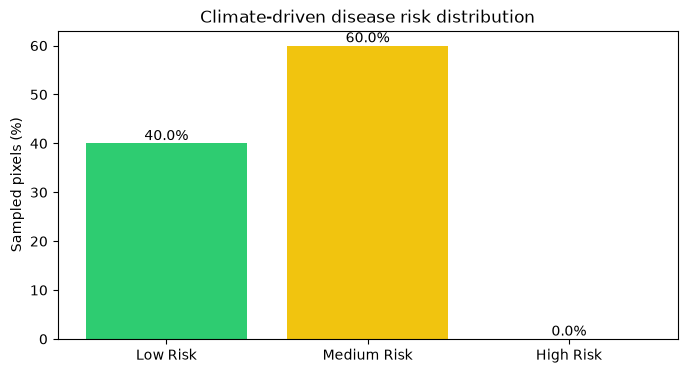

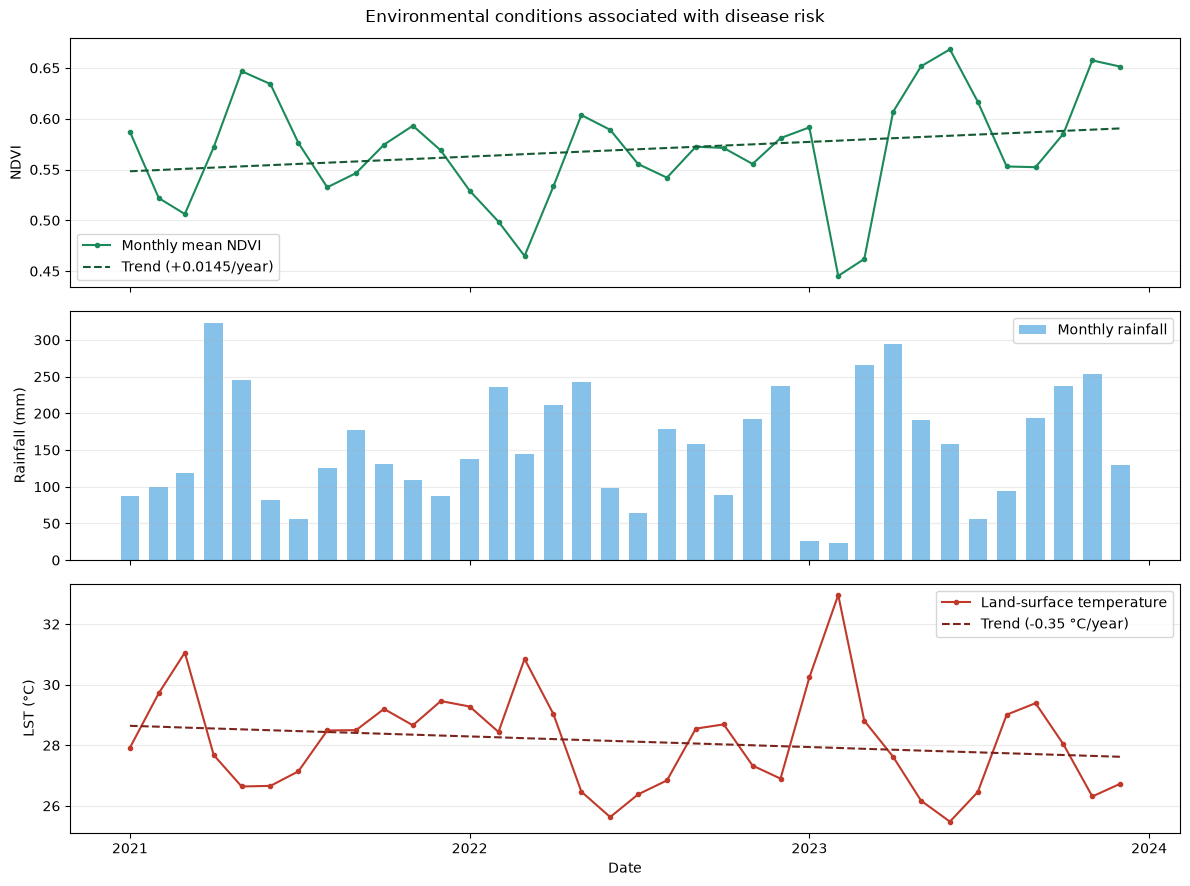

In [6]:
risk = output.charts.get("riskDist", {})
if risk.get("labels"):
    fig, ax = plt.subplots(figsize=(8, 4))
    bars = ax.bar(risk["labels"], risk["data"], color=risk.get("colors"))
    ax.bar_label(bars, fmt="%.1f%%")
    ax.set_ylabel("Sampled pixels (%)")
    ax.set_title("Climate-driven disease risk distribution")
    plt.show()

series = output.charts.get("timeSeries", {})
datasets = {d["label"]: d["data"] for d in series.get("datasets", [])}
dates = pd.to_datetime(series.get("labels", []))
values = {
    "NDVI": np.asarray(datasets.get("NDVI", []), dtype=float),
    "Rainfall": np.asarray(datasets.get("Monthly rain (mm)", []), dtype=float),
    "LST": np.asarray(datasets.get("LST (°C)", []), dtype=float),
}

if len(dates):
    fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=True)
    months = np.arange(len(dates), dtype=float)

    ndvi = values["NDVI"]
    if ndvi.size:
        axes[0].plot(dates, ndvi, color="#1B8A5A", marker="o",
                     markersize=3, label="Monthly mean NDVI")
        valid = np.isfinite(ndvi)
        if valid.sum() >= 2:
            slope, intercept = np.polyfit(months[valid], ndvi[valid], 1)
            axes[0].plot(dates, intercept + slope * months, "--",
                         color="#145A32",
                         label=f"Trend ({slope * 12:+.4f}/year)")
    axes[0].set_ylabel("NDVI")
    axes[0].legend()

    rain = values["Rainfall"]
    if rain.size:
        axes[1].bar(dates, rain, width=20, color="#5DADE2", alpha=0.75,
                    label="Monthly rainfall")
    axes[1].set_ylabel("Rainfall (mm)")
    axes[1].legend()

    temp = values["LST"]
    if temp.size:
        axes[2].plot(dates, temp, color="#C0392B", marker="o",
                     markersize=3, label="Land-surface temperature")
        valid = np.isfinite(temp)
        if valid.sum() >= 2:
            slope, intercept = np.polyfit(months[valid], temp[valid], 1)
            axes[2].plot(dates, intercept + slope * months, "--",
                         color="#7B241C",
                         label=f"Trend ({slope * 12:+.2f} °C/year)")
    axes[2].set_ylabel("LST (°C)")
    axes[2].set_xlabel("Date")
    axes[2].legend()
    axes[2].xaxis.set_major_locator(mdates.YearLocator())
    axes[2].xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

    for ax in axes:
        ax.grid(axis="y", alpha=0.25)
    fig.suptitle("Environmental conditions associated with disease risk")
    fig.tight_layout()
    plt.show()


### 7b. Population exposure

Climate suitability alone does not tell a health ministry where to send
resources — the same suitability score covers an empty reserve and a
market town very differently. Alongside `riskDist`'s percentage-of-sampled-
pixels view, the pipeline performs a raster zonal sum of WorldPop population
counts against the disease-risk classification:

- `stats['total_population']`: population inside the AOI covered by the
  risk raster;
- `stats['population_affected']`: population in **Medium Risk + High Risk**
  zones (`DISEASE_AT_RISK_LABELS`);
- `riskDist['data_population']`: population per class, parallel to the
  existing percentage `data` array.

Population fetch is best-effort (`fetch_population_count_safe`) — if
WorldPop was unavailable for this AOI/year, these fields are simply absent
rather than crashing the analysis.


Total population in AOI: 4,918,113
Population in Medium/High disease-risk zones: 3,362,070 (68.4%)


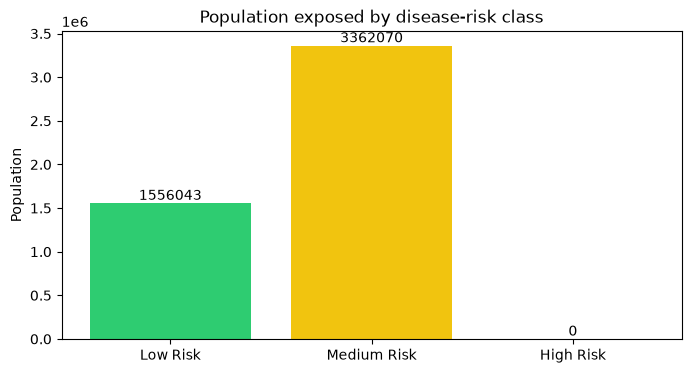

In [7]:
total_population = output.stats.get("total_population")
population_affected = output.stats.get("population_affected")

if total_population is not None:
    print(f"Total population in AOI: {total_population:,.0f}")
    print(
        f"Population in Medium/High disease-risk zones: {population_affected:,.0f} "
        f"({population_affected / total_population:.1%})"
    )

    risk = output.charts.get("riskDist", {})
    pop_data = risk.get("data_population")
    if pop_data:
        fig, ax = plt.subplots(figsize=(8, 4))
        bars = ax.bar(risk["labels"], pop_data, color=risk.get("colors"))
        ax.bar_label(bars, fmt="%.0f")
        ax.set_ylabel("Population")
        ax.set_title("Population exposed by disease-risk class")
        plt.show()
else:
    print("Population data was not available for this AOI/year.")


## 8. Locate spatial artifacts

The analysis may produce GeoJSON features and one or more Cloud-Optimized GeoTIFF
files. GeoJSON is convenient for APIs and interactive maps, while COGs preserve
continuous raster coverage for GIS software and cloud-native access.

The following cell reports the artifacts without attempting to display a large
raster inside the notebook.


In [8]:
print("GeoJSON type:", output.geojson.get("type"))
print("GeoJSON features:", len(output.geojson.get("features", [])))
print("Raster path(s):", output.raster_path)

if output.raster_path:
    paths = (
        output.raster_path.values()
        if isinstance(output.raster_path, dict)
        else [output.raster_path]
    )
    for path in paths:
        artifact = Path(path)
        print(f"{artifact.name}: exists={artifact.exists()}")


GeoJSON type: FeatureCollection
GeoJSON features: 2477
Raster path(s): {'disease_risk': '/home/odero-george/Workspace/climate-change/outputs/kisumu_disease_risk_disease_risk.tif'}
kisumu_disease_risk_disease_risk.tif: exists=True


## 9. Optional: generate a PDF report

Setting `GENERATE_REPORT` to `True` reruns the same request and asks the package to
assemble a PDF containing metadata, statistics, charts, interpretation text, and
available map content. Keep it `False` during exploration to avoid an unnecessary
second model run.


In [9]:
GENERATE_REPORT = True

if GENERATE_REPORT:
    report_output = await run_analysis(
        **analysis_args,
        report_output_dir=str(REPORT_DIR),
    )
    print("Report:", report_output.metadata.get("report_path"))

Report: /home/odero-george/Workspace/climate-change/reports/disease_20260813_154429.pdf
